<a href="https://colab.research.google.com/github/joaovitor10jvpc/inferencia/blob/main/inferencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scipy

In [ ]:

from scipy.stats import chisquare, chi2_contingency, chi2
from scipy.stats import relfreq
import numpy as np

**HIPÓTESE NULA (H0):** O dado é justo (as frequências observadas são iguais às esperadas).


**HIPÓTESE ALTERNATIVA (H1)**: O dado não é justo (as frequências observadas diferem das esperadas).


In [ ]:
confianca = 0.95
alpha = 1 - confianca

# Frequências que você observou (ex: faces de um dado)
observado = [1175, 44, 169, 111, 112,731,96,110,171,65 ]

# Frequências esperadas (se o dado for justo e jogado 60 vezes)
esperado = [278.4 ] * 10

gl = len(observado) - 1  # graus de liberdade


# O Python calcula o valor de qui-quadrado e o p-valor automaticamente
qui_quadrado, p_valor = chisquare(f_obs=observado, f_exp=esperado)

print(f"Valor de qui-quadrado: {qui_quadrado}")
print("p_Valor: " ,p_valor)

if p_valor < alpha:
    print("H0 foi rejeitado. ")

else:
    print("H1 foi rejeitado.")




Valor de qui-quadrado: 4490.173850574713
p_Valor:  0.0
H0 foi rejeitado. 


In [ ]:
valor_critico = chi2.ppf(1 - alpha, gl)

print(f"Valor Crítico: {valor_critico}")

Valor Crítico: 16.918977604620448


<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_5512/27139070.py:14: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(x, y, 'b-', lw=2, label=f'Distribuição $\chi^2$ (gl={gl})')
/tmp/ipykernel_5512/27139070.py:32: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('Estatística $\chi^2$')


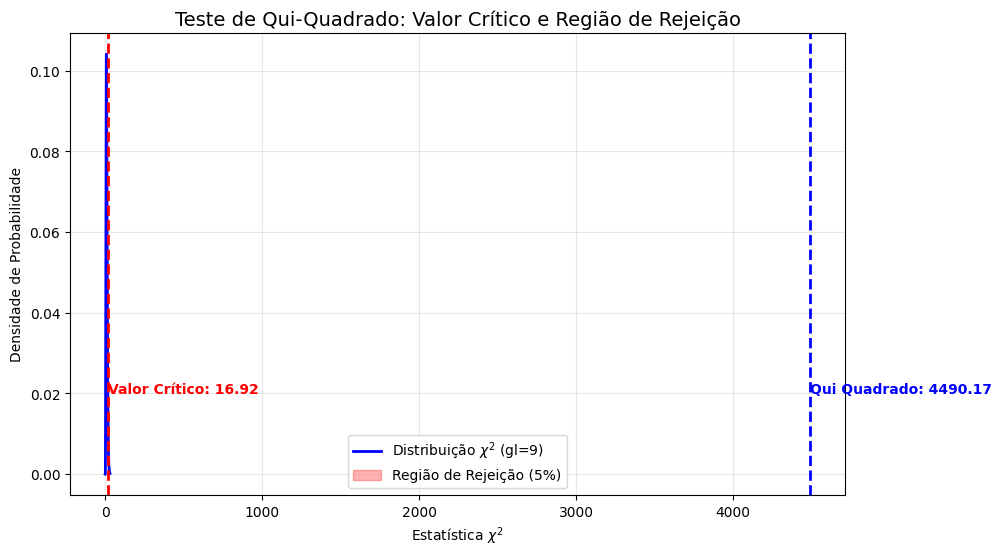

In [ ]:

import matplotlib.pyplot as plt


valor_critico = chi2.ppf(confianca, gl)



x = np.linspace(0, 30, 500)
y = chi2.pdf(x, gl) # Densidade de probabilidade



plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', lw=2, label=f'Distribuição $\chi^2$ (gl={gl})')

# 5. Destacar a Região de Rejeição (Cauda Direita)
x_rejeicao = np.linspace(valor_critico, 30, 100)
plt.fill_between(x_rejeicao, chi2.pdf(x_rejeicao, gl), color='red', alpha=0.3, label='Região de Rejeição (5%)')

# 6. Adicionar a linha do Valor Crítico
plt.axvline(valor_critico, color='red', linestyle='--', lw=2)
plt.text(valor_critico + 0.5, 0.02, f'Valor Crítico: {valor_critico:.2f}',
         color='red', fontweight='bold')

plt.axvline(qui_quadrado, color='blue', linestyle='--', lw=2 )
plt.text(qui_quadrado + 0.5, 0.02, f'Qui Quadrado: {qui_quadrado:.2f}',
         color = 'blue', fontweight='bold')

#
# 7. Estilização
plt.title('Teste de Qui-Quadrado: Valor Crítico e Região de Rejeição', fontsize=14)
plt.xlabel('Estatística $\chi^2$')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()




    **H0** p1 = 0.301 , p2 = 0.176, p3 = 0.125, p4 = 0.097,p5 = 0.079, p6 = 0.067, p7=0.058, p8= 0.051, p9=0.046

    **H1** NEGAÇÃO DE H0

  

In [ ]:
esperado = np.array([0.301, 0.176, 0.125, 0.097, 0.079, 0.067, 0.058, 0.051, 0.046])
esperado = esperado * 271


observado = np.array([69, 40, 42, 26,25,16,16,17,20])


valor_critico = chi2.ppf(1 - alpha, df=gl)

#observado = relfreq(a, numbins=9).frequency
print("valor crítico",valor_critico)

qui_quadrado, p_valor = chisquare(f_obs=observado, f_exp=esperado)
print(f"Valor de qui-quadrado: {qui_quadrado}")
print(f"Valor de p: {p_valor}")

if p_valor < alpha:
    print("H1 foi rejeitado ")

else:
    print("h0 foi rejeitado.")


### experimentos com tabela de contingência ###



valor crítico 16.918977604620448
Valor de qui-quadrado: 11.279176659945339
Valor de p: 0.18637684886143602
h0 foi rejeitado.


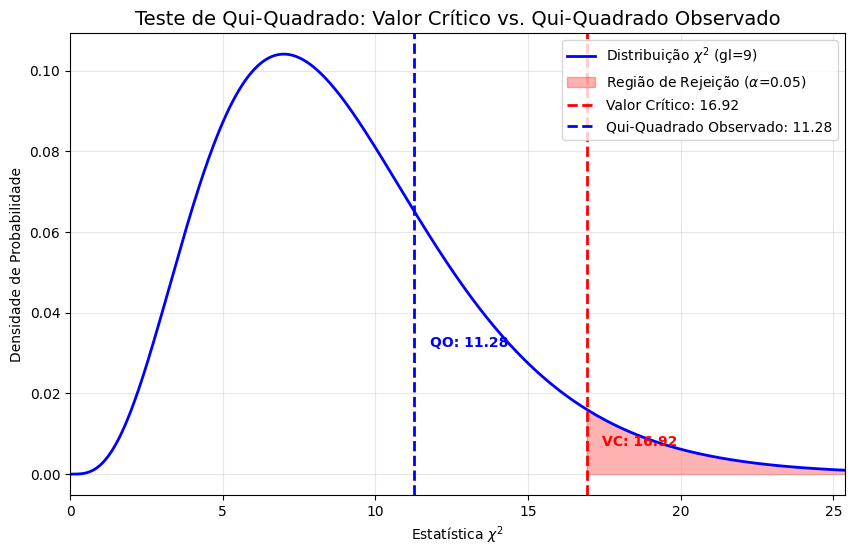

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

# Reusing gl, valor_critico, qui_quadrado from the previous test
# gl = 9
# valor_critico = 16.918977604620448
# qui_quadrado = 11.279176659945339
# confianca = 0.95 (used to determine rejection region for valor_critico)

x_max_plot = max(qui_quadrado * 1.5, valor_critico * 1.5, 25) # Adjust max x-axis for better visualization
x = np.linspace(0, x_max_plot, 500)
y = chi2.pdf(x, gl) # Probability density function

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', lw=2, label=rf'Distribuição $\chi^2$ (gl={gl})')

# Highlight the Rejection Region (Right Tail)
x_rejeicao = np.linspace(valor_critico, x_max_plot, 100)
plt.fill_between(x_rejeicao, chi2.pdf(x_rejeicao, gl), color='red', alpha=0.3, label=r'Região de Rejeição ($\alpha$=0.05)')

# Add the Critical Value line
plt.axvline(valor_critico, color='red', linestyle='--', lw=2, label=f'Valor Crítico: {valor_critico:.2f}')
plt.text(valor_critico + x_max_plot * 0.02, chi2.pdf(valor_critico, gl) * 0.5, f'VC: {valor_critico:.2f}', color='red', fontweight='bold', va='center')

# Add the Observed Chi-squared value line
plt.axvline(qui_quadrado, color='blue', linestyle='--', lw=2, label=f'Qui-Quadrado Observado: {qui_quadrado:.2f}')
plt.text(qui_quadrado + x_max_plot * 0.02, chi2.pdf(qui_quadrado, gl) * 0.5, f'QO: {qui_quadrado:.2f}', color='blue', fontweight='bold', va='center')

# Styling
plt.title('Teste de Qui-Quadrado: Valor Crítico vs. Qui-Quadrado Observado', fontsize=14)
plt.xlabel(r'Estatística $\chi^2$') # Fixed syntax warning here
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, x_max_plot)
plt.show()

In [ ]:
observado = np.array([[18.34, 70.66], [368.66, 1420.340]])

observed_chi2_statistic, p_valor, dof, expected = chi2_contingency(observado)
print(f"Valor de qui-quadrado: {observed_chi2_statistic}")

print(f"Valor de p: {p_valor}")

if p_valor < alpha:
    print("H0 foi rejeitado ")
else:
    print("h1 foi rejeitado")

Valor de qui-quadrado: 0.0
Valor de p: 1.0
h1 foi rejeitado


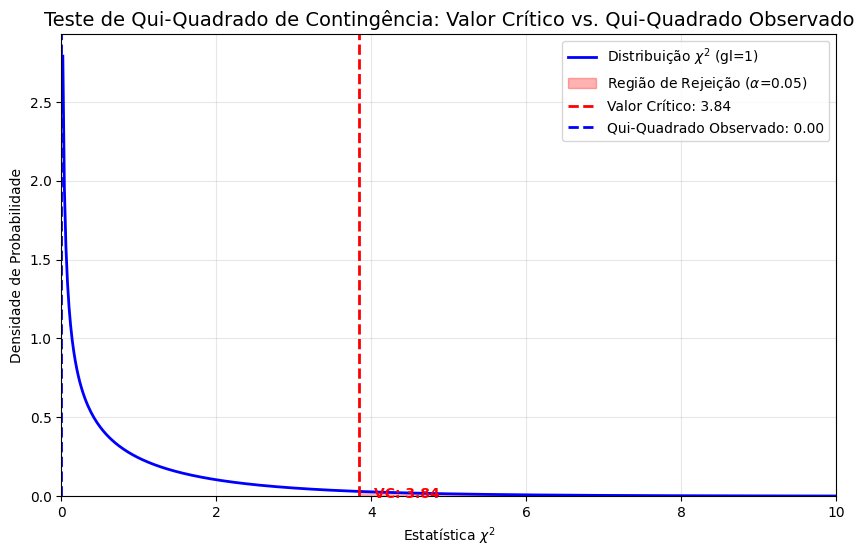

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

# Variables from the last executed cell (chi2_contingency test)
# observed_chi2_statistic (observed statistic), p_valor, dof (degrees of freedom), expected
# alpha from previous cell (0.05)

# Recalculate critical value for the contingency test's dof
valor_critico_contingency = chi2.ppf(1 - alpha, df=dof)

x_max_plot = max(observed_chi2_statistic * 2, valor_critico_contingency * 2, 10) # Adjust max x-axis for better visualization
x = np.linspace(0, x_max_plot, 500)
y = chi2.pdf(x, dof) # Probability density function for dof=1

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', lw=2, label=rf'Distribuição $\chi^2$ (gl={dof})')

# Highlight the Rejection Region (Right Tail)
x_rejeicao = np.linspace(valor_critico_contingency, x_max_plot, 100)
plt.fill_between(x_rejeicao, chi2.pdf(x_rejeicao, dof), color='red', alpha=0.3, label=r'Região de Rejeição ($\alpha$=0.05)')

# Add the Critical Value line
plt.axvline(valor_critico_contingency, color='red', linestyle='--', lw=2, label=f'Valor Crítico: {valor_critico_contingency:.2f}')
plt.text(valor_critico_contingency + x_max_plot * 0.02, chi2.pdf(valor_critico_contingency, dof) * 0.5, f'VC: {valor_critico_contingency:.2f}', color='red', fontweight='bold', va='center')

# Add the Observed Chi-squared value line from the contingency test
plt.axvline(observed_chi2_statistic, color='blue', linestyle='--', lw=2, label=f'Qui-Quadrado Observado: {observed_chi2_statistic:.2f}')
plt.text(observed_chi2_statistic + x_max_plot * 0.02, chi2.pdf(observed_chi2_statistic, dof) * 0.5, f'QO: {observed_chi2_statistic:.2f}', color='blue', fontweight='bold', va='center')

# Styling
plt.title('Teste de Qui-Quadrado de Contingência: Valor Crítico vs. Qui-Quadrado Observado', fontsize=14)
plt.xlabel(r'Estatística $\chi^2$')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, x_max_plot)
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.show()